# 01 Exploratory Analysis — Proyecto de Modelado

## Caso: Predicción de abandono de clientes

Este notebook corresponde a la primera etapa del proyecto: **análisis exploratorio de datos (EDA)**.

El objetivo es comprender la estructura del dataset, revisar calidad de datos, detectar problemas iniciales, visualizar patrones relevantes y dejar una base analítica sólida para los notebooks posteriores de modelado, evaluación y optimización.

**Problema de negocio:** una empresa de servicios digitales por suscripción quiere anticipar qué clientes podrían abandonar el servicio para diseñar acciones preventivas de retención.

**Variable objetivo:** `abandono`

- `0`: cliente no abandona.
- `1`: cliente abandona.

Como la variable objetivo es binaria, el problema principal corresponde a **clasificación binaria**.


## 1. Importación de librerías

Se utilizan librerías estándar del ecosistema de Ciencia de Datos en Python:

- `pandas`: manipulación y análisis de datos.
- `numpy`: operaciones numéricas.
- `matplotlib` y `seaborn`: visualización de datos.
- `pathlib`: manejo ordenado de rutas del proyecto.

Los gráficos se configuran con tamaños legibles, títulos claros y una paleta uniforme para evitar visualizaciones recargadas.


In [ ]:
# Importa pandas para cargar, explorar y manipular el dataset.
import pandas as pd

# Importa numpy para operaciones numéricas y manejo de valores especiales.
import numpy as np

# Importa matplotlib para generar visualizaciones base.
import matplotlib.pyplot as plt

# Importa seaborn para crear gráficos estadísticos más claros.
import seaborn as sns

# Importa Path para trabajar rutas de archivos de forma más ordenada.
from pathlib import Path

# Configura el tamaño general de los gráficos para mejorar la legibilidad.
plt.rcParams["figure.figsize"] = (10, 5)

# Configura el tamaño de fuente de los gráficos.
plt.rcParams["font.size"] = 10

# Define un estilo visual limpio para los gráficos.
sns.set_theme(style="whitegrid")


## 2. Carga del dataset

En esta etapa se carga el archivo `dataset_clientes.csv`, correspondiente al caso de estudio de abandono de clientes.

Se valida que el archivo exista antes de leerlo, ya que una entrega reproducible debe controlar errores básicos de ruta o disponibilidad de datos.


In [ ]:
def cargar_datos(url):
    """ Función que recibe la url del archivo a leer """
    df = pd.read_csv(url)
    print("Dataset cargado correctamente")
    print(df.head(5))
    return df

url = "https://raw.githubusercontent.com/magomezn-debug/dScience_001D/main/data/dataset_clientes.csv"

# para cargar datos
df = cargar_datos(url)

# Muestra las dimensiones del dataset: filas y columnas.
print("Dimensiones del dataset:", df.shape)

# Muestra las primeras filas para revisar visualmente la estructura inicial.
df.head()

Dimensiones del dataset: (2763, 22)


,id_cliente,fecha_registro,edad,genero,region,estado_civil,ingreso_mensual,gasto_mensual,deuda_total,score_crediticio,...,ultima_compra_dias,uso_app,tipo_plan,num_productos,tiene_tarjeta_credito,canal_registro,dia_semana_registro,hora_registro,codigo_postal,abandono
0,1,2021-10-27,66,Otro,Norte,Divorciado,9.243057e+05,524088.303055,2.448145e+06,455.406680,...,356,Bajo,Estandar,3,1,Tienda,Lunes,22.0,3824.0,1.0
1,2,2018-08-25,51,Masculino,Centro,Soltero,1.384687e+06,314259.751474,1.620569e+06,575.048508,...,307,Medio,Premium,4,1,App,Martes,10.0,4148.0,0.0
2,3,2019-05-25,48,Femenino,Norte,Casado,NaN,387192.316142,5.395040e+06,770.716904,...,232,Alto,Premium,4,1,App,Jueves,6.0,7200.0,0.0
3,4,2022-04-20,54,Masculino,Sur,Casado,4.369032e+05,417328.601856,2.999350e+06,442.722671,...,165,Alto,Estandar,2,1,App,Domingo,16.0,1782.0,1.0
4,5,2020-03-19,31,Otro,Centro,Soltero,7.408561e+05,490961.191253,1.637711e+06,468.188403,...,283,Bajo,Estandar,3,1,Web,Martes,8.0,3448.0,1.0


## 3. Comprensión inicial de los datos

Antes de limpiar o modelar, es necesario entender qué contiene el dataset.

Esta revisión permite identificar:

- cantidad de filas y columnas,
- tipos de datos,
- variables numéricas,
- variables categóricas,
- variable objetivo,
- posibles columnas que no deberían usarse directamente como predictoras.

Esta etapa es importante porque un modelo predictivo solo puede ser tan bueno como la calidad y comprensión de los datos que recibe.


In [ ]:
# Muestra información general del dataset: columnas, tipos de datos y valores no nulos.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2763 entries, 0 to 2762
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id_cliente             2763 non-null   int64  
 1   fecha_registro         2763 non-null   object 
 2   edad                   2763 non-null   int64  
 3   genero                 2763 non-null   object 
 4   region                 2763 non-null   object 
 5   estado_civil           2763 non-null   object 
 6   ingreso_mensual        2638 non-null   float64
 7   gasto_mensual          2614 non-null   float64
 8   deuda_total            2763 non-null   float64
 9   score_crediticio       2623 non-null   float64
 10  antiguedad_meses       2763 non-null   int64  
 11  frecuencia_compra      2763 non-null   int64  
 12  ultima_compra_dias     2763 non-null   int64  
 13  uso_app                2763 non-null   object 
 14  tipo_plan              2763 non-null   object 
 15  num_

In [ ]:
# Calcula estadísticos descriptivos para variables numéricas.
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id_cliente,2763.0,1.382000e+03,7.977537e+02,1.000000e+00,6.915000e+02,1.382000e+03,2.072500e+03,2.763000e+03
edad,2763.0,4.857655e+01,1.779864e+01,1.800000e+01,3.400000e+01,4.900000e+01,6.300000e+01,7.900000e+01
ingreso_mensual,2638.0,8.314558e+05,4.305902e+05,-1.697937e+04,6.346399e+05,8.041210e+05,9.739780e+05,7.560936e+06
gasto_mensual,2614.0,4.027706e+05,1.497411e+05,-1.556012e+05,3.030005e+05,4.033185e+05,4.994664e+05,9.055726e+05
deuda_total,2763.0,2.049643e+06,1.112657e+06,-1.094121e+06,1.437929e+06,1.983640e+06,2.539744e+06,1.543400e+07
score_crediticio,2623.0,5.999173e+02,1.016193e+02,2.803099e+02,5.318028e+02,6.006895e+02,6.654771e+02,9.390915e+02
antiguedad_meses,2763.0,6.043757e+01,3.455128e+01,1.000000e+00,3.000000e+01,6.200000e+01,8.900000e+01,1.190000e+02
frecuencia_compra,2763.0,9.840029e+00,5.500553e+00,1.000000e+00,5.000000e+00,1.000000e+01,1.500000e+01,1.900000e+01
ultima_compra_dias,2763.0,1.827734e+02,1.045811e+02,1.000000e+00,9.200000e+01,1.820000e+02,2.760000e+02,3.640000e+02
num_productos,2763.0,3.007600e+00,1.403786e+00,1.000000e+00,2.000000e+00,3.000000e+00,4.000000e+00,5.000000e+00


In [ ]:
# Calcula estadísticos descriptivos para variables categóricas.
df.describe(include=["object"]).T

,count,unique,top,freq
fecha_registro,2763,1496,2022-04-09,7
genero,2763,3,Otro,971
region,2763,3,Sur,973
estado_civil,2763,3,Soltero,947
uso_app,2763,3,Bajo,939
tipo_plan,2763,3,Estandar,946
canal_registro,2763,4,App,939
dia_semana_registro,2762,7,Sabado,421


## 4. Revisión de calidad de datos

En esta sección se revisan problemas comunes de calidad:

- duplicados completos,
- valores faltantes,
- distribución de la variable objetivo,
- tipos de variables,
- posibles columnas identificadoras.

Esta revisión no consiste en modificar datos automáticamente, sino en diagnosticar el estado inicial del dataset para justificar decisiones posteriores.


In [ ]:
# Calcula la cantidad de filas completamente duplicadas.
duplicados = df.duplicated().sum()

# Muestra el resultado de duplicados completos.
print("Cantidad de filas duplicadas completas:", duplicados)

# Calcula valores faltantes por columna y los ordena de mayor a menor.
nulos = df.isna().sum().sort_values(ascending=False)

# Muestra solo columnas que tienen valores faltantes.
print("\nValores nulos por columna:")
print(nulos[nulos > 0])

# Muestra la distribución absoluta de la variable objetivo.
print("\nDistribución absoluta de abandono:")
print(df["abandono"].value_counts())

# Muestra la distribución porcentual de la variable objetivo.
print("\nDistribución porcentual de abandono:")
print((df["abandono"].value_counts(normalize=True) * 100).round(2))

Cantidad de filas duplicadas completas: 0

Valores nulos por columna:
gasto_mensual          149
score_crediticio       140
ingreso_mensual        125
abandono                 1
hora_registro            1
dia_semana_registro      1
codigo_postal            1
dtype: int64

Distribución absoluta de abandono:
abandono
0.0    1650
1.0    1112
Name: count, dtype: int64

Distribución porcentual de abandono:
abandono
0.0    59.74
1.0    40.26
Name: proportion, dtype: float64


### Interpretación de calidad de datos

La revisión de duplicados permite detectar si existen registros repetidos que puedan sesgar estadísticas o modelos. En un contexto de clientes, eliminar duplicados sin revisar identificadores puede ser riesgoso, ya que dos clientes distintos podrían compartir características similares.

Los valores faltantes deben analizarse según el tipo de variable. En variables numéricas, una imputación por media o mediana puede ser adecuada dependiendo de la distribución y presencia de outliers. En variables categóricas, puede usarse la moda o una categoría explícita como `"Desconocido"`.

La distribución de `abandono` es especialmente importante porque permite detectar si existe desbalance de clases. Si una clase domina demasiado, métricas como `accuracy` pueden ser engañosas, por lo que en notebooks posteriores se evaluarán métricas como `precision`, `recall`, `F1-score` y `ROC-AUC`.


## 5. Clasificación conceptual de variables

No basta con mirar si una columna está almacenada como `int64`, `float64` u `object`. En Ciencia de Datos importa el significado real de la variable.

Por ejemplo:

- `edad`, `ingreso_mensual` y `gasto_mensual` son variables numéricas.
- `genero`, `region`, `estado_civil` y `tipo_plan` son variables categóricas.
- `abandono` y `tiene_tarjeta_credito` son binarias.
- `id_cliente` es un identificador, no una variable predictora útil.
- `fecha_registro` puede transformarse para extraer información temporal, pero no debe tratarse simplemente como texto.


In [ ]:
# Identifica columnas numéricas según pandas.
columnas_numericas = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Identifica columnas categóricas según pandas.
columnas_categoricas = df.select_dtypes(include=["object", "category"]).columns.tolist()

# Define columnas que no deberían tratarse como predictoras directas.
columnas_identificadoras = ["id_cliente"]

# Muestra columnas numéricas detectadas.
print("Columnas numéricas detectadas:")
print(columnas_numericas)

# Muestra columnas categóricas detectadas.
print("\nColumnas categóricas detectadas:")
print(columnas_categoricas)

# Muestra columnas identificadoras.
print("\nColumnas identificadoras:")
print(columnas_identificadoras)

Columnas numéricas detectadas:
['id_cliente', 'edad', 'ingreso_mensual', 'gasto_mensual', 'deuda_total', 'score_crediticio', 'antiguedad_meses', 'frecuencia_compra', 'ultima_compra_dias', 'num_productos', 'tiene_tarjeta_credito', 'hora_registro', 'codigo_postal', 'abandono']

Columnas categóricas detectadas:
['fecha_registro', 'genero', 'region', 'estado_civil', 'uso_app', 'tipo_plan', 'canal_registro', 'dia_semana_registro']

Columnas identificadoras:
['id_cliente']


## 6. Visualización 1 — Distribución de la variable objetivo `abandono`

Este gráfico permite comprender el problema central del caso: cuántos clientes abandonan y cuántos permanecen.

Se utiliza un gráfico de barras porque `abandono` es una variable categórica/binaria. Este tipo de gráfico permite comparar claramente la frecuencia de cada clase.


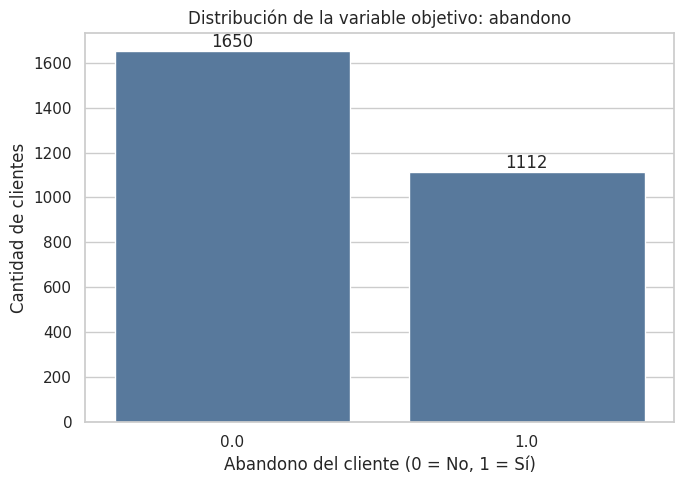

In [ ]:
# Crea una nueva figura para el gráfico.
plt.figure(figsize=(7, 5))

# Genera un gráfico de barras con la distribución de la variable objetivo.
ax = sns.countplot(data=df, x="abandono", color="#4C78A8")

# Define un título claro para el gráfico.
plt.title("Distribución de la variable objetivo: abandono")

# Define la etiqueta del eje X.
plt.xlabel("Abandono del cliente (0 = No, 1 = Sí)")

# Define la etiqueta del eje Y.
plt.ylabel("Cantidad de clientes")

# Agrega etiquetas numéricas sobre cada barra.
for container in ax.containers:
    ax.bar_label(container)

# Ajusta márgenes para evitar cortes visuales.
plt.tight_layout()

# Guarda el gráfico en la carpeta de resultados.
plt.savefig(PLOTS_PATH / "01_distribucion_abandono.png", dpi=150)

# Muestra el gráfico.
plt.show()

### Análisis del gráfico

El gráfico muestra la proporción de clientes que abandonan frente a los que permanecen. Esta visualización es clave porque define el contexto del problema de clasificación.

Si existe una diferencia marcada entre ambas clases, el proyecto debe considerar métricas más robustas que `accuracy`, ya que un modelo podría obtener buen porcentaje de acierto simplemente prediciendo siempre la clase mayoritaria.

**Valor para el negocio:** conocer la proporción de abandono ayuda a dimensionar la gravedad del problema y justificar acciones de retención. Si el abandono es relevante, la empresa puede priorizar campañas preventivas hacia clientes con mayor riesgo.


## 7. Visualización 2 — Distribución de edad

La edad es una variable numérica relevante porque puede influir en comportamiento de consumo, uso de plataformas digitales y permanencia en servicios de suscripción.

Se utiliza un histograma porque permite observar la distribución de una variable numérica continua/discreta y detectar concentraciones de clientes en ciertos rangos.


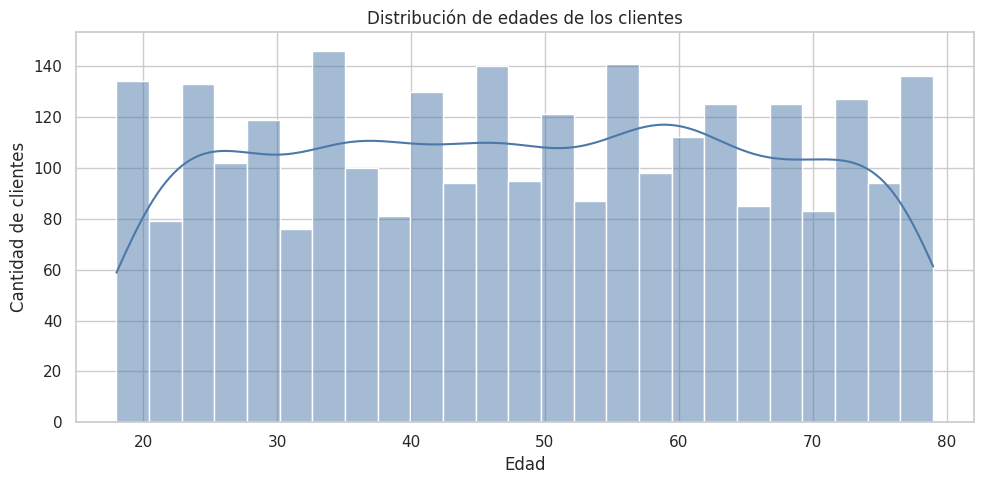

In [ ]:
# Crea una figura para el histograma.
plt.figure(figsize=(10, 5))

# Genera histograma de edad con curva de densidad.
sns.histplot(data=df, x="edad", bins=25, kde=True, color="#4C78A8")

# Define título descriptivo.
plt.title("Distribución de edades de los clientes")

# Define etiqueta del eje X.
plt.xlabel("Edad")

# Define etiqueta del eje Y.
plt.ylabel("Cantidad de clientes")

# Ajusta el diseño para evitar solapamientos.
plt.tight_layout()

# Guarda el gráfico.
plt.savefig(PLOTS_PATH / "02_distribucion_edad.png", dpi=150)

# Muestra el gráfico.
plt.show()

### Análisis del gráfico

La distribución de edad permite identificar qué grupos etarios predominan en la base de clientes. Esto es importante porque distintos rangos de edad pueden tener comportamientos distintos frente a servicios digitales.

Si se observa concentración en adultos jóvenes o adultos de mediana edad, la empresa puede adaptar mensajes, planes y estrategias de retención según ese perfil.

**Valor para el negocio:** permite orientar campañas y analizar si ciertos segmentos etarios presentan mayor riesgo de abandono en análisis posteriores.


## 8. Visualización 3 — Ingreso mensual según abandono

El ingreso mensual es una variable económica que puede estar relacionada con la permanencia en un servicio por suscripción.

Se utiliza un boxplot porque permite comparar distribuciones entre dos grupos: clientes que abandonan y clientes que no abandonan. Además, permite detectar dispersión y valores atípicos.


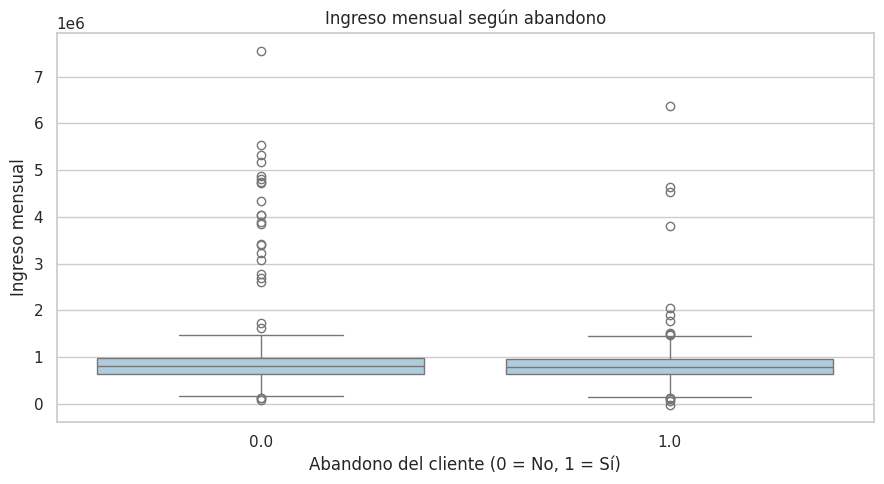

In [ ]:
# Crea una figura para el boxplot.
plt.figure(figsize=(9, 5))

# Genera boxplot comparando ingreso mensual según abandono.
sns.boxplot(data=df, x="abandono", y="ingreso_mensual", color="#A6CEE3")

# Define título del gráfico.
plt.title("Ingreso mensual según abandono")

# Define etiqueta del eje X.
plt.xlabel("Abandono del cliente (0 = No, 1 = Sí)")

# Define etiqueta del eje Y.
plt.ylabel("Ingreso mensual")

# Ajusta el diseño visual.
plt.tight_layout()

# Guarda el gráfico.
plt.savefig(PLOTS_PATH / "03_ingreso_mensual_abandono.png", dpi=150)

# Muestra el gráfico.
plt.show()

### Análisis del gráfico

El boxplot permite comparar si existen diferencias en ingresos entre clientes que abandonan y clientes que permanecen. Si los clientes que abandonan tienden a concentrarse en ciertos niveles de ingreso, esta variable podría aportar información útil para el modelo predictivo.

La presencia de outliers debe interpretarse con cuidado. Un ingreso extremo no necesariamente es error; puede representar clientes reales de alto poder adquisitivo. Por eso no se deben eliminar automáticamente.

**Valor para el negocio:** ayuda a entender si el factor económico influye en la retención y si conviene diseñar estrategias diferenciadas por capacidad de pago.


## 9. Visualización 4 — Gasto mensual según abandono

El gasto mensual puede reflejar compromiso, uso o nivel de consumo del cliente dentro del servicio.

Se utiliza un boxplot para comparar la distribución del gasto entre clientes que abandonan y no abandonan.


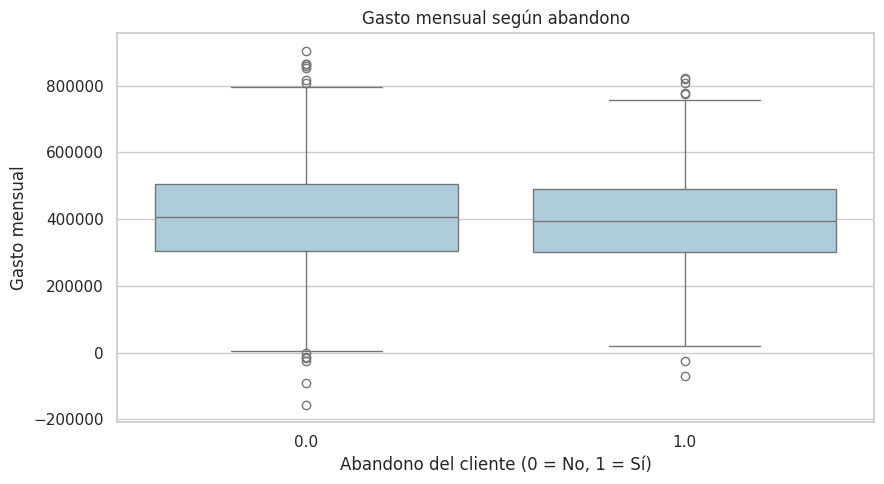

In [ ]:
# Crea una figura para el boxplot.
plt.figure(figsize=(9, 5))

# Genera boxplot comparando gasto mensual según abandono.
sns.boxplot(data=df, x="abandono", y="gasto_mensual", color="#A6CEE3")

# Define título claro.
plt.title("Gasto mensual según abandono")

# Define etiqueta del eje X.
plt.xlabel("Abandono del cliente (0 = No, 1 = Sí)")

# Define etiqueta del eje Y.
plt.ylabel("Gasto mensual")

# Ajusta márgenes.
plt.tight_layout()

# Guarda el gráfico.
plt.savefig(PLOTS_PATH / "04_gasto_mensual_abandono.png", dpi=150)

# Muestra el gráfico.
plt.show()

### Análisis del gráfico

Este gráfico permite analizar si los clientes con mayor o menor gasto mensual presentan diferencias en la tendencia de abandono.

Si los clientes con bajo gasto tienden a abandonar más, podría interpretarse como baja vinculación con el servicio. Si clientes con alto gasto abandonan, el impacto económico para la empresa puede ser mayor.

**Valor para el negocio:** permite identificar segmentos críticos para campañas de retención, especialmente clientes cuyo abandono generaría mayor pérdida de ingresos.


## 10. Visualización 5 — Tipo de plan y abandono

El tipo de plan es una variable categórica nominal que representa la modalidad contratada por el cliente.

Se utiliza un gráfico de barras agrupadas porque permite comparar la cantidad de clientes que abandonan y no abandonan dentro de cada tipo de plan.


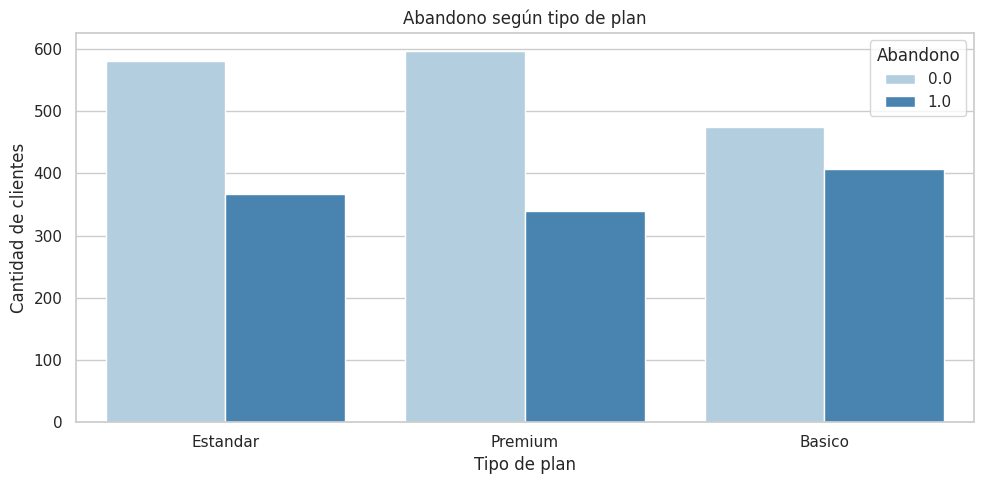

In [ ]:
# Crea una figura para el gráfico de barras.
plt.figure(figsize=(10, 5))

# Genera gráfico de barras agrupadas por tipo de plan y abandono.
ax = sns.countplot(data=df, x="tipo_plan", hue="abandono", palette="Blues")

# Define título del gráfico.
plt.title("Abandono según tipo de plan")

# Define etiqueta del eje X.
plt.xlabel("Tipo de plan")

# Define etiqueta del eje Y.
plt.ylabel("Cantidad de clientes")

# Define título de la leyenda.
plt.legend(title="Abandono")

# Rota etiquetas si fuera necesario.
plt.xticks(rotation=0)

# Ajusta diseño.
plt.tight_layout()

# Guarda gráfico.
plt.savefig(PLOTS_PATH / "05_tipo_plan_abandono.png", dpi=150)

# Muestra gráfico.
plt.show()

### Análisis del gráfico

Este gráfico permite evaluar si ciertos planes concentran más abandono que otros. El tipo de plan puede reflejar nivel de compromiso, costo percibido o satisfacción del cliente con el servicio contratado.

No basta con observar volumen absoluto; en etapas posteriores conviene calcular tasas de abandono por plan para evitar conclusiones sesgadas por categorías con más clientes.

**Valor para el negocio:** ayuda a detectar planes que podrían requerir mejoras, beneficios adicionales o campañas específicas de retención.


## 11. Visualización 6 — Uso de app y abandono

La variable `uso_app` es relevante porque mide comportamiento digital del cliente. En servicios digitales, el nivel de uso puede estar relacionado con satisfacción, hábito y permanencia.

Se utiliza un gráfico de barras agrupadas para comparar abandono según nivel de uso de la aplicación.


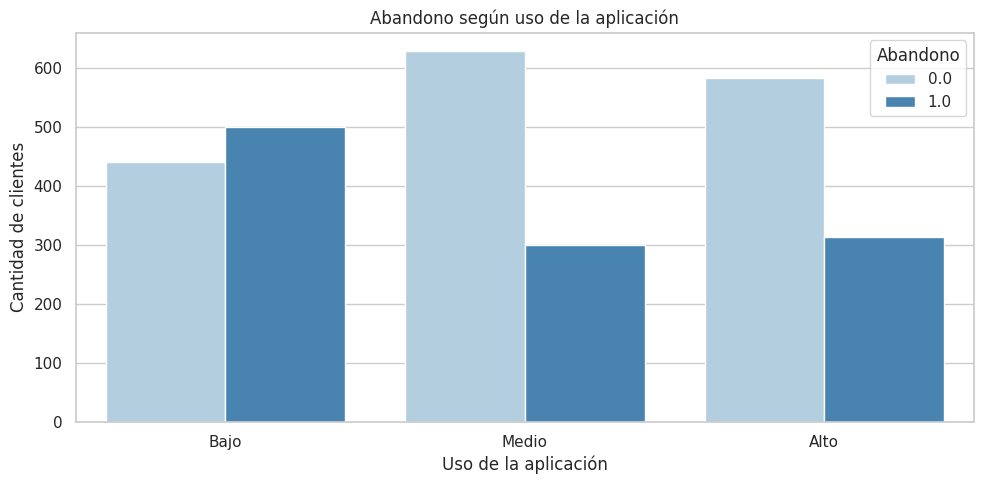

In [ ]:
# Crea figura para el gráfico.
plt.figure(figsize=(10, 5))

# Genera gráfico de barras por uso de app y abandono.
ax = sns.countplot(data=df, x="uso_app", hue="abandono", palette="Blues")

# Define título.
plt.title("Abandono según uso de la aplicación")

# Define etiqueta del eje X.
plt.xlabel("Uso de la aplicación")

# Define etiqueta del eje Y.
plt.ylabel("Cantidad de clientes")

# Define leyenda.
plt.legend(title="Abandono")

# Ajusta diseño.
plt.tight_layout()

# Guarda gráfico.
plt.savefig(PLOTS_PATH / "06_uso_app_abandono.png", dpi=150)

# Muestra gráfico.
plt.show()

### Análisis del gráfico

El uso de la aplicación puede ser una señal importante de compromiso del cliente. Clientes con bajo uso podrían tener menor vínculo con el servicio y mayor riesgo de abandono.

Este gráfico permite observar si el abandono se concentra en niveles específicos de uso. Si se confirma esta relación, la empresa podría activar campañas de engagement antes de que el cliente cancele.

**Valor para el negocio:** permite diseñar alertas tempranas basadas en comportamiento digital.


## 12. Visualización 7 — Frecuencia de compra según abandono

La frecuencia de compra es una variable de comportamiento. Puede indicar qué tan activo es el cliente dentro del ecosistema de la empresa.

Se utiliza un boxplot para comparar la distribución de frecuencia de compra entre quienes abandonan y quienes permanecen.


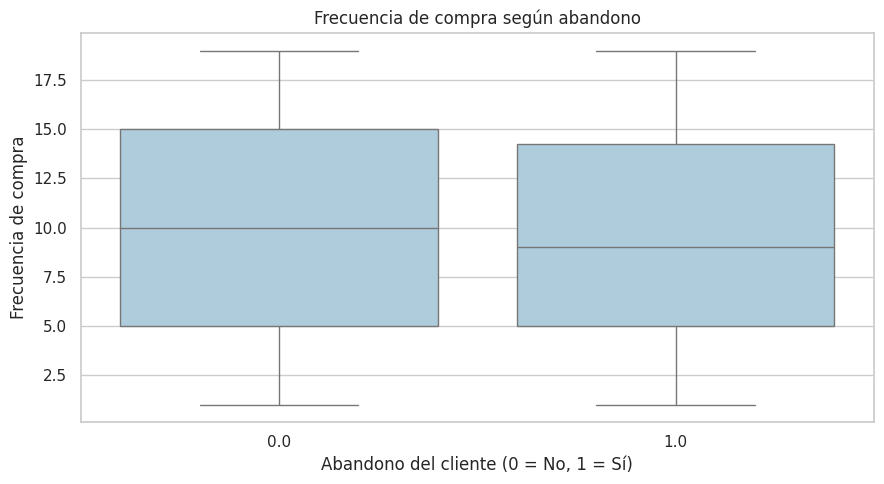

In [ ]:
# Crea figura para el boxplot.
plt.figure(figsize=(9, 5))

# Genera boxplot de frecuencia de compra según abandono.
sns.boxplot(data=df, x="abandono", y="frecuencia_compra", color="#A6CEE3")

# Define título.
plt.title("Frecuencia de compra según abandono")

# Define etiqueta X.
plt.xlabel("Abandono del cliente (0 = No, 1 = Sí)")

# Define etiqueta Y.
plt.ylabel("Frecuencia de compra")

# Ajusta gráfico.
plt.tight_layout()

# Guarda gráfico.
plt.savefig(PLOTS_PATH / "07_frecuencia_compra_abandono.png", dpi=150)

# Muestra gráfico.
plt.show()

### Análisis del gráfico

La frecuencia de compra puede reflejar nivel de actividad del cliente. Si los clientes que abandonan tienen menor frecuencia, se refuerza la idea de que baja interacción puede anticipar cancelación.

Si existen clientes con alta frecuencia que igualmente abandonan, podrían representar casos importantes para investigar: quizá abandonan por precio, mala experiencia o mejores ofertas de competidores.

**Valor para el negocio:** permite construir indicadores tempranos de riesgo de abandono.


## 13. Visualización 8 — Correlación entre variables numéricas

La matriz de correlación permite observar relaciones lineales entre variables numéricas.

Esta visualización ayuda a detectar variables relacionadas entre sí, posibles redundancias y relaciones preliminares con la variable objetivo.


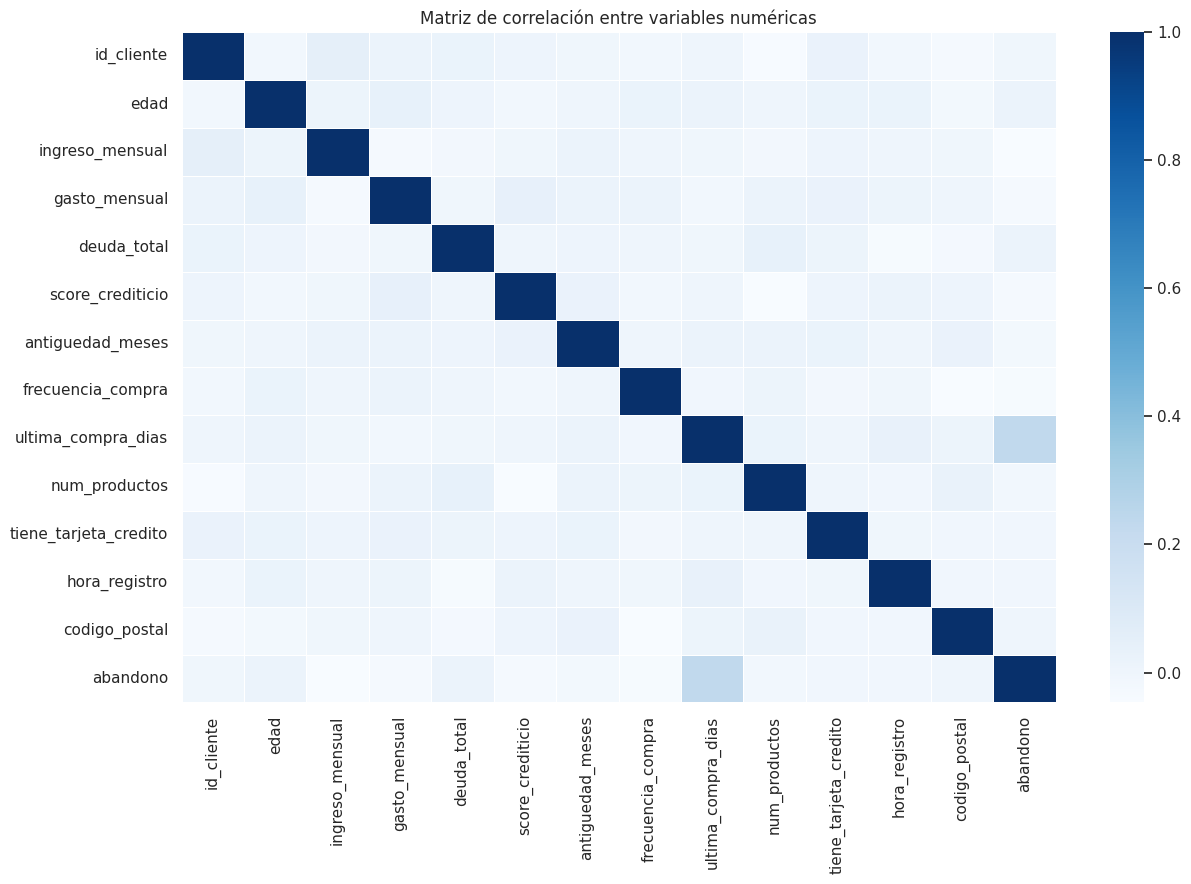

In [ ]:
# Selecciona solo columnas numéricas.
df_numerico = df.select_dtypes(include=["int64", "float64"])

# Calcula matriz de correlación.
correlacion = df_numerico.corr()

# Crea figura para el mapa de calor.
plt.figure(figsize=(13, 9))

# Genera heatmap de correlaciones.
sns.heatmap(correlacion, annot=False, cmap="Blues", linewidths=0.5)

# Define título.
plt.title("Matriz de correlación entre variables numéricas")

# Ajusta diseño.
plt.tight_layout()

# Guarda gráfico.
plt.savefig(PLOTS_PATH / "08_matriz_correlacion.png", dpi=150)

# Muestra gráfico.
plt.show()

### Análisis del gráfico

La matriz de correlación ayuda a comprender relaciones entre variables numéricas. Una correlación alta entre dos variables puede indicar redundancia, mientras que una correlación con `abandono` puede sugerir relevancia predictiva.

Es importante recordar que correlación no implica causalidad. Esta visualización orienta el análisis, pero no prueba que una variable cause el abandono.

**Valor para el negocio:** permite detectar variables potencialmente relevantes para modelos y evitar interpretaciones simplistas.


## 14. Visualización 9 — Score crediticio según abandono

El score crediticio puede reflejar estabilidad financiera o perfil de riesgo del cliente.

Se utiliza un boxplot para comparar la distribución del score entre clientes que abandonan y no abandonan.


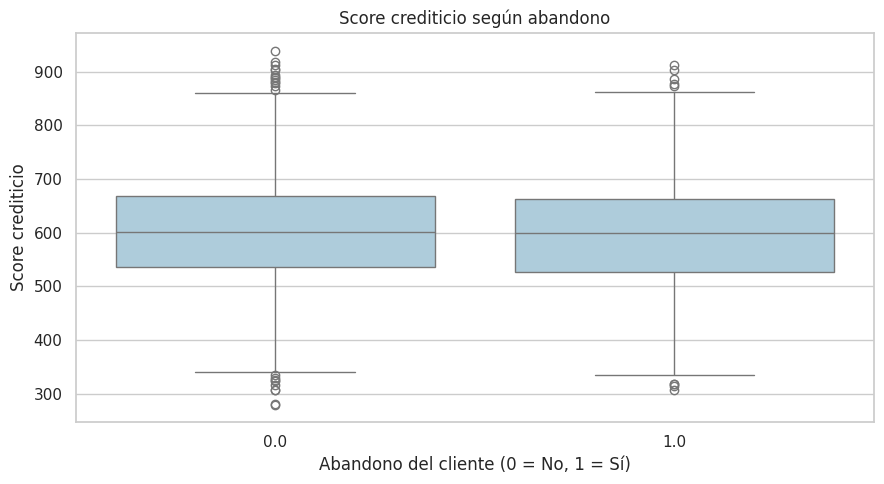

In [ ]:
# Crea figura para el boxplot.
plt.figure(figsize=(9, 5))

# Genera boxplot de score crediticio por abandono.
sns.boxplot(data=df, x="abandono", y="score_crediticio", color="#A6CEE3")

# Define título.
plt.title("Score crediticio según abandono")

# Define etiqueta X.
plt.xlabel("Abandono del cliente (0 = No, 1 = Sí)")

# Define etiqueta Y.
plt.ylabel("Score crediticio")

# Ajusta diseño.
plt.tight_layout()

# Guarda gráfico.
plt.savefig(PLOTS_PATH / "09_score_crediticio_abandono.png", dpi=150)

# Muestra gráfico.
plt.show()

### Análisis del gráfico

El score crediticio puede ayudar a identificar si existe una relación entre perfil financiero y abandono. Si los clientes con menor score abandonan más, podría existir una conexión entre estabilidad financiera y permanencia.

Sin embargo, esta variable debe usarse con cuidado ético, ya que puede representar características sensibles desde el punto de vista financiero.

**Valor para el negocio:** permite evaluar riesgo de abandono desde una perspectiva financiera, sin perder de vista la responsabilidad en el uso de datos.


## 15. Visualización 10 — Última compra en días según abandono

La variable `ultima_compra_dias` mide cuántos días han pasado desde la última compra. Esta variable puede ser un indicador fuerte de inactividad.

Se utiliza un boxplot para comparar inactividad reciente entre clientes que abandonan y no abandonan.


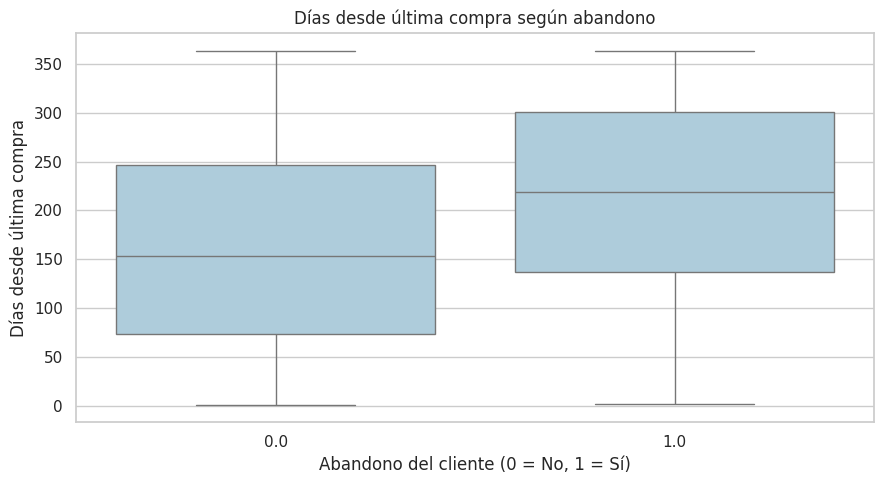

In [ ]:
# Crea figura para el boxplot.
plt.figure(figsize=(9, 5))

# Genera boxplot de última compra en días según abandono.
sns.boxplot(data=df, x="abandono", y="ultima_compra_dias", color="#A6CEE3")

# Define título.
plt.title("Días desde última compra según abandono")

# Define etiqueta X.
plt.xlabel("Abandono del cliente (0 = No, 1 = Sí)")

# Define etiqueta Y.
plt.ylabel("Días desde última compra")

# Ajusta diseño.
plt.tight_layout()

# Guarda gráfico.
plt.savefig(PLOTS_PATH / "10_ultima_compra_abandono.png", dpi=150)

# Muestra gráfico.
plt.show()

### Análisis del gráfico

La cantidad de días desde la última compra puede ser una señal de desinterés o desconexión del servicio. Si los clientes que abandonan presentan más días sin comprar, esta variable puede ser muy útil para anticipar abandono.

**Valor para el negocio:** permite crear alertas preventivas. Por ejemplo, si un cliente pasa demasiados días sin comprar o interactuar, la empresa podría activar campañas de retención antes de que abandone.


## 16. Conclusiones del análisis exploratorio

El análisis exploratorio permitió comprender la estructura del dataset y detectar variables relevantes para el problema de abandono.

Los principales hallazgos son:

1. La variable objetivo `abandono` confirma que el problema es de clasificación binaria.
2. Las variables de comportamiento, como `uso_app`, `frecuencia_compra` y `ultima_compra_dias`, son especialmente relevantes para anticipar abandono.
3. Las variables económicas, como `ingreso_mensual`, `gasto_mensual`, `deuda_total` y `score_crediticio`, pueden aportar información útil, pero deben interpretarse con criterio.
4. Existen variables categóricas que requerirán codificación mediante One Hot Encoding.
5. Existen variables numéricas que deberán escalarse para modelos sensibles a magnitudes, como SVM, KNN y Logistic Regression.
6. Los outliers no deben eliminarse automáticamente, ya que podrían representar comportamientos válidos del negocio.
7. El dataset queda preparado conceptualmente para las siguientes etapas: modelado supervisado, evaluación comparativa y optimización de hiperparámetros.

Desde el punto de vista del negocio, este EDA permite identificar señales tempranas de abandono y orientar el desarrollo de modelos predictivos que ayuden a priorizar acciones de retención.
